# Pandas Basics — More Useful Methods — Workbook

___

## Dataset
### *The Pudding*'s Film Dialogue Data

The dataset that we're working with in this lesson is taken from Hannah Andersen and Matt Daniels's *Pudding* essay, ["Film Dialogue from 2,000 screenplays, Broken Down by Gender and Age"](https://pudding.cool/2017/03/film-dialogue/). The dataset provides information about 2,000 films from 1925 to 2015, including characters’ names, genders, ages, how many words each character spoke in each film, the release year of each film, and how much money the film grossed. They included character gender information because they wanted to contribute data to a broader conversation about how "white men dominate movie roles."

___

## Import Pandas

To use the Pandas library, we first need to `import` it.

In [1]:
import pandas as pd

## Change Display Settings

By default, Pandas will display 60 rows and 20 columns. I often change [Pandas' default display settings](https://pandas.pydata.org/pandas-docs/stable/user_guide/options.html) to show more rows or columns.

In [2]:
pd.options.display.max_rows = 200

## Get Data

For this notebook, we're going to read in a slightly less clean version of the Pudding data.

In [4]:
film_df = pd.read_csv('Pudding-Film-Dialogue-Salty.csv', delimiter=",", encoding='utf-8')

## Overview

To look at a random *n* number of rows in a DataFrame, we can use a method called `.sample()`.

In [11]:
film_df.sample(5)

,script_id,character,words,gender,age,imdb_id,title,release_year,gross,proportion_of_dialogue
10248,3302,rosalie,948,f,28.0,tt0376874,Sexual Life,2005,NaN,0.052474
18541,7050,const. frank st,582,m,30.0,tt0109642,Dolores Claiborne,1995,48.0,0.071201
14275,4711,john mitchell,511,m,81.0,tt0113987,Nixon,1995,27.0,0.019664
16366,5484,gretel,212,f,NaN,tt3172532,The Diary of a Teenage Girl,2015,1.0,0.022640
11524,3694,claire spencer,6298,f,42.0,tt0161081,What Lies Beneath,2000,250.0,0.469230


Generate information about all the columns in the data 

In [ ]:
film_df.describe()

,script_id,imdb_character_name,words,gender,age,imdb_id,title,year,gross,proportion_of_dialogue
count,23052.000000,23050,23052.000000,23052,18266.000000,23052,23052,23052.000000,19390.000000,23052.000000
unique,NaN,17613,NaN,3,NaN,2000,1994,NaN,NaN,NaN
top,NaN,doctor,NaN,m,NaN,tt0116905,Lone Star,NaN,NaN,NaN
freq,NaN,36,NaN,16135,NaN,40,40,NaN,NaN,NaN
mean,4195.580904,NaN,907.870684,NaN,42.386839,NaN,NaN,1998.133828,106.805570,0.086512
std,2473.518048,NaN,1399.538583,NaN,59.714730,NaN,NaN,14.745342,145.992394,0.107740
min,280.000000,NaN,101.000000,NaN,3.000000,NaN,NaN,1929.000000,0.000000,0.001537
25%,2095.000000,NaN,193.000000,NaN,30.000000,NaN,NaN,1992.000000,22.000000,0.019771
50%,3694.000000,NaN,396.000000,NaN,39.000000,NaN,NaN,2001.000000,56.000000,0.042421
75%,6234.000000,NaN,980.000000,NaN,50.000000,NaN,NaN,2009.000000,136.000000,0.104166


## Rename Columns

In [8]:
film_df = film_df.rename(columns={'imdb_character_name': 'character', 'year': 'release_year'})

## Clean and Transform Data

### Pandas `.str` Methods

Remember all the special things that you can do with Python strings aka [string methods](https://melaniewalsh.github.io/Intro-Cultural-Analytics/Python/String-Methods.html)?

Pandas has special [Pandas string methods](https://pandas.pydata.org/pandas-docs/stable/user_guide/text.html#string-methods), too. Many of them are very similar to Python string methods, except they will transform every single string value in a column, and we have to add `.str` to the method chain.

| **Pandas String Method** | **Explanation**                                                                                   |
|:-------------:|:---------------------------------------------------------------------------------------------------:|
| df['column_name']`.str.lower()`         | makes the string in each row lowercase                                                                                |
| df['column_name']`.str.upper()`         | makes the string in each row uppercase                                                |
| df['column_name']`.str.title()`         | makes the string in each row titlecase                                                |
| df['column_name']`.str.replace('old string', 'new string')`      | replaces `old string` with `new string` for each row |
| df['column_name']`.str.contains('some string')`      | tests whether string in each row contains "some string" |
| df['column_name']`.str.split('delim')`          | returns a list of substrings separated by the given delimiter |
| df['column_name']`.str.join(list)`         | opposite of split(), joins the elements in the given list together using the string                                                                        |
                                                            

For example, to transform every character's name in the "character" column from lowercase to title case, we can use `.str.title()` 

To transform every character's name in the "character" column to lowercase, we can use `.str.lower()`

In [ ]:
film_df['character']

In [12]:
film_df['character'].str.title()

0                  Betty
1        Carolyn Johnson
2                Eleanor
3        Francesca Johns
4                  Madge
              ...       
23047            Maurice
23048    Monsieur D'Arqu
23049         Mrs. Potts
23050           Wardrobe
23051         Mrs. Potts
Name: character, Length: 23052, dtype: object

The transformation above was temporary. Change the DataFrame column "character" to title case permanently.

In [1]:
#Your code here

## Filter with `.contains()`

We can use the `.str.contains()` to search for particular words or phrases in a column, such as "Star Wars."

In [15]:
star_wars_filter = film_df['title'].str.contains('Star Wars')

In [17]:
film_df[star_wars_filter].sort_values(by="release_year")

,script_id,character,words,gender,age,imdb_id,title,release_year,gross,proportion_of_dialogue
3068,1362,princess leia o,636,f,21.0,tt0076759,Star Wars: Episode IV - A New Hope,1977,1798.0,0.063334
3058,1362,ben obi-wan ken,995,m,63.0,tt0076759,Star Wars: Episode IV - A New Hope,1977,1798.0,0.099084
3061,1362,darth vader,492,m,46.0,tt0076759,Star Wars: Episode IV - A New Hope,1977,1798.0,0.048994
3062,1362,general dodonna,185,m,66.0,tt0076759,Star Wars: Episode IV - A New Hope,1977,1798.0,0.018423
3063,1362,grand moff tark,411,m,64.0,tt0076759,Star Wars: Episode IV - A New Hope,1977,1798.0,0.040928
3064,1362,greedo,103,m,33.0,tt0076759,Star Wars: Episode IV - A New Hope,1977,1798.0,0.010257
3065,1362,han solo,1730,m,35.0,tt0076759,Star Wars: Episode IV - A New Hope,1977,1798.0,0.172276
3066,1362,jabba,185,m,NaN,tt0076759,Star Wars: Episode IV - A New Hope,1977,1798.0,0.018423
3067,1362,luke skywalker,2485,m,26.0,tt0076759,Star Wars: Episode IV - A New Hope,1977,1798.0,0.247461
3069,1362,red leader,241,m,37.0,tt0076759,Star Wars: Episode IV - A New Hope,1977,1798.0,0.023999


In [18]:
twilight_filter = film_df['title'].str.contains('Twilight')

In [19]:
film_df[twilight_filter]

,script_id,character,words,gender,age,imdb_id,title,release_year,gross,proportion_of_dialogue
11261,3621,alice cullen,146,f,21.0,tt1099212,Twilight,2008,231.0,0.010193
11262,3621,angela,250,f,18.0,tt1099212,Twilight,2008,231.0,0.017453
11263,3621,bella swan,4934,f,18.0,tt1099212,Twilight,2008,231.0,0.344457
11264,3621,billy black,148,m,55.0,tt1099212,Twilight,2008,231.0,0.010332
11265,3621,charlie swan,1256,m,42.0,tt1099212,Twilight,2008,231.0,0.087685
11266,3621,edward cullen,3680,m,22.0,tt1099212,Twilight,2008,231.0,0.256911
11267,3621,eric,308,m,27.0,tt1099212,Twilight,2008,231.0,0.021502
11268,3621,esme cullen,162,f,33.0,tt1099212,Twilight,2008,231.0,0.011310
11269,3621,jacob black,342,m,16.0,tt1099212,Twilight,2008,231.0,0.023876
11270,3621,james,778,m,26.0,tt1099212,Twilight,2008,231.0,0.054314


Make your own filter with `.str.contains()`

In [37]:
film_df.dropna(inplace=True)
new_filter = film_df['character'].str.contains('Ben')

In [38]:
film_df[new_filter]

,script_id,character,words,gender,age,imdb_id,title,release_year,gross,proportion_of_dialogue
14588,4863,Benjamin Coffin,670,m,34.0,tt0294870,Rent,2005,39.0,0.077762
15776,5342,Benny Zadir,318,m,46.0,tt0120770,A Night at the Roxbury,1998,56.0,0.021738
20712,7983,President Benne,291,m,64.0,tt0109444,Clear and Present Danger,1994,253.0,0.065807
21903,8543,Ben,3230,m,30.0,tt0478087,21,2008,98.0,0.328921


## Applying Functions

You can apply Python functions to DataFrames with multiple different methods. We will explore two of them here.

Let's say we want to transform the "gross" column, which reports how much money each film made, into a full number. Right now if a film made $2 million, it simply says `2.0`. But maybe we want it to say `20000000`.

In [39]:
def make_millions(number):
    new_number = number * 1000000
    return new_number

In [40]:
make_millions(2.0)

2000000.0

### Method 1

You can use regular Python to loop through the Series `film_df['gross']` and make a list with all your new values.

In [41]:
gross_in_millions = []
for gross in film_df['gross']:
    gross_mill = make_millions(gross)
    gross_in_millions.append(gross_mill)

Then you can add that list as a new column to the DataFrame.

In [42]:
film_df['gross_millions'] = gross_in_millions

In [43]:
film_df

,script_id,character,words,gender,age,imdb_id,title,release_year,gross,proportion_of_dialogue,gross_millions
0,280,betty,311,f,35.0,tt0112579,The Bridges of Madison County,1995,142.0,0.048639,142000000.0
3,280,francesca johns,2251,f,46.0,tt0112579,The Bridges of Madison County,1995,142.0,0.352049,142000000.0
4,280,madge,190,f,46.0,tt0112579,The Bridges of Madison County,1995,142.0,0.029715,142000000.0
5,280,michael johnson,723,m,38.0,tt0112579,The Bridges of Madison County,1995,142.0,0.113075,142000000.0
6,280,robert kincaid,1908,m,65.0,tt0112579,The Bridges of Madison County,1995,142.0,0.298405,142000000.0
...,...,...,...,...,...,...,...,...,...,...,...
23047,9254,maurice,1107,m,71.0,tt0101414,Beauty and the Beast,1991,452.0,0.108967,452000000.0
23048,9254,monsieur d'arqu,114,m,58.0,tt0101414,Beauty and the Beast,1991,452.0,0.011222,452000000.0
23049,9254,mrs. potts,564,f,66.0,tt0101414,Beauty and the Beast,1991,452.0,0.055517,452000000.0
23050,9254,wardrobe,121,f,54.0,tt0101414,Beauty and the Beast,1991,452.0,0.011911,452000000.0


### Method 2

You can directly apply a function to every row in a column (or Series) with a special Pandas methods called `.apply()`.

In [44]:
film_df['gross_millions2'] = film_df['gross'].apply(make_millions)

In [45]:
film_df

,script_id,character,words,gender,age,imdb_id,title,release_year,gross,proportion_of_dialogue,gross_millions,gross_millions2
0,280,betty,311,f,35.0,tt0112579,The Bridges of Madison County,1995,142.0,0.048639,142000000.0,142000000.0
3,280,francesca johns,2251,f,46.0,tt0112579,The Bridges of Madison County,1995,142.0,0.352049,142000000.0,142000000.0
4,280,madge,190,f,46.0,tt0112579,The Bridges of Madison County,1995,142.0,0.029715,142000000.0,142000000.0
5,280,michael johnson,723,m,38.0,tt0112579,The Bridges of Madison County,1995,142.0,0.113075,142000000.0,142000000.0
6,280,robert kincaid,1908,m,65.0,tt0112579,The Bridges of Madison County,1995,142.0,0.298405,142000000.0,142000000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
23047,9254,maurice,1107,m,71.0,tt0101414,Beauty and the Beast,1991,452.0,0.108967,452000000.0,452000000.0
23048,9254,monsieur d'arqu,114,m,58.0,tt0101414,Beauty and the Beast,1991,452.0,0.011222,452000000.0,452000000.0
23049,9254,mrs. potts,564,f,66.0,tt0101414,Beauty and the Beast,1991,452.0,0.055517,452000000.0,452000000.0
23050,9254,wardrobe,121,f,54.0,tt0101414,Beauty and the Beast,1991,452.0,0.011911,452000000.0,452000000.0


Let's transform the column `proportion_of_dialogue` into a percentage, e.g., .02 -> 2.

Make a Python function called `make_percent()` that will take in a number and then return that number mutlipled by 100.

In [50]:
def make_percent(proportion):
    percent = round(proportion*100)
    return percent


Make a new column "percentage_of_dialogue" by applying this function to the "proportion of dialogue" column.

In [51]:
film_df['percentage_of_dialogue'] = film_df['proportion_of_dialogue'].apply(make_percent)
film_df

,script_id,character,words,gender,age,imdb_id,title,release_year,gross,proportion_of_dialogue,gross_millions,gross_millions2,percentage_of_dialogue
0,280,betty,311,f,35.0,tt0112579,The Bridges of Madison County,1995,142.0,0.048639,142000000.0,142000000.0,5
3,280,francesca johns,2251,f,46.0,tt0112579,The Bridges of Madison County,1995,142.0,0.352049,142000000.0,142000000.0,35
4,280,madge,190,f,46.0,tt0112579,The Bridges of Madison County,1995,142.0,0.029715,142000000.0,142000000.0,3
5,280,michael johnson,723,m,38.0,tt0112579,The Bridges of Madison County,1995,142.0,0.113075,142000000.0,142000000.0,11
6,280,robert kincaid,1908,m,65.0,tt0112579,The Bridges of Madison County,1995,142.0,0.298405,142000000.0,142000000.0,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23047,9254,maurice,1107,m,71.0,tt0101414,Beauty and the Beast,1991,452.0,0.108967,452000000.0,452000000.0,11
23048,9254,monsieur d'arqu,114,m,58.0,tt0101414,Beauty and the Beast,1991,452.0,0.011222,452000000.0,452000000.0,1
23049,9254,mrs. potts,564,f,66.0,tt0101414,Beauty and the Beast,1991,452.0,0.055517,452000000.0,452000000.0,6
23050,9254,wardrobe,121,f,54.0,tt0101414,Beauty and the Beast,1991,452.0,0.011911,452000000.0,452000000.0,1


## More Useful Methods

### Make a Series into a DataFrame

Here's a Series:

In [52]:
film_df.groupby('title')['words'].sum()

title
(500) Days of Summer          18192
10 Things I Hate About You    19476
12 Years a Slave              16552
127 Hours                      5145
1408                           3323
                              ...  
Zero Dark Thirty              12641
Zero Effect                   13815
Zodiac                        13356
eXistenZ                       9311
xXx                            7931
Name: words, Length: 1657, dtype: int64

You can make a Series object into a DataFrame object by using two square brackets instead of one.

In [53]:
film_df.groupby('title')[['words']].sum()

,words
title,
(500) Days of Summer,18192
10 Things I Hate About You,19476
12 Years a Slave,16552
127 Hours,5145
1408,3323
...,...
Zero Dark Thirty,12641
Zero Effect,13815
Zodiac,13356


But perhaps the most useful method, especially after grouping by a category, is to use `.reset_index()`. The index is "reset" to ascending numbers, and the groupby category becomes a regular column.

In [54]:
film_df.groupby('title')[['words']].sum().reset_index()

,title,words
0,(500) Days of Summer,18192
1,10 Things I Hate About You,19476
2,12 Years a Slave,16552
3,127 Hours,5145
4,1408,3323
...,...,...
1652,Zero Dark Thirty,12641
1653,Zero Effect,13815
1654,Zodiac,13356
1655,eXistenZ,9311


### Change Data Types

You can convert data types with `.astype()` ([documentation here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.astype.html)).

In [55]:
film_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15555 entries, 0 to 23051
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   script_id               15555 non-null  int64  
 1   character               15555 non-null  object 
 2   words                   15555 non-null  int64  
 3   gender                  15555 non-null  object 
 4   age                     15555 non-null  float64
 5   imdb_id                 15555 non-null  object 
 6   title                   15555 non-null  object 
 7   release_year            15555 non-null  int64  
 8   gross                   15555 non-null  float64
 9   proportion_of_dialogue  15555 non-null  float64
 10  gross_millions          15555 non-null  float64
 11  gross_millions2         15555 non-null  float64
 12  percentage_of_dialogue  15555 non-null  int64  
dtypes: float64(5), int64(4), object(4)
memory usage: 1.7+ MB


In [56]:
film_df['script_id'].astype('str')

0         280
3         280
4         280
5         280
6         280
         ... 
23047    9254
23048    9254
23049    9254
23050    9254
23051    9254
Name: script_id, Length: 15555, dtype: object

Try to convert "age" to an integer and see what happens...

In [62]:
film_df['age'].astype(int)

0        35
3        46
4        46
5        38
6        65
         ..
23047    71
23048    58
23049    66
23050    54
23051    66
Name: age, Length: 15555, dtype: int64

Pandas says that you cannot convert NaN values to integers. If we're ok with keeping the Nan values, we can simply choose to "ignore" the errors.

In [60]:
film_df['age'].astype(int, errors='ignore')

0        35
3        46
4        46
5        38
6        65
         ..
23047    71
23048    58
23049    66
23050    54
23051    66
Name: age, Length: 15555, dtype: int64

Convert to a datetime data type

In [63]:
pd.to_datetime(film_df['release_year'], format='%Y')

0       1995-01-01
3       1995-01-01
4       1995-01-01
5       1995-01-01
6       1995-01-01
           ...    
23047   1991-01-01
23048   1991-01-01
23049   1991-01-01
23050   1991-01-01
23051   1991-01-01
Name: release_year, Length: 15555, dtype: datetime64[ns]

### Binning

You can use `pd.cut()` to bin values ([documentation here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html)).

In [64]:
pd.cut(film_df['age'], bins=[0, 25, 50, 75, 100], labels= ['0-25', '25-50', '50-75', '75-100'])

0        25-50
3        25-50
4        25-50
5        25-50
6        50-75
         ...  
23047    50-75
23048    50-75
23049    50-75
23050    50-75
23051    50-75
Name: age, Length: 15555, dtype: category
Categories (4, object): ['0-25' < '25-50' < '50-75' < '75-100']

In [65]:
binned_age = pd.cut(film_df['age'], bins=[0, 25, 50, 75, 100], labels= ['0-25', '25-50', '50-75', '75-100'])

<Axes: xlabel='age'>

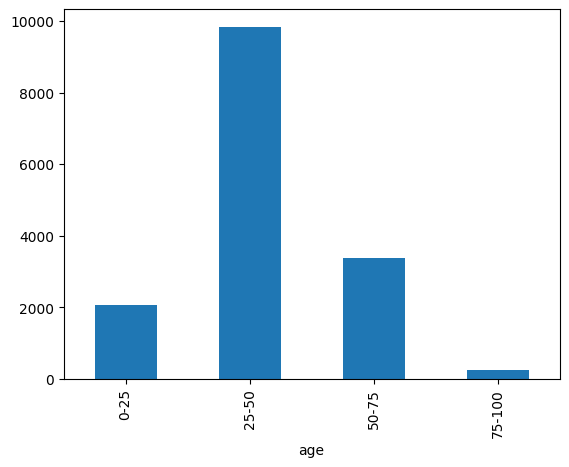

In [70]:
binned_age.value_counts().sort_index().plot(kind='bar')

<Axes: >

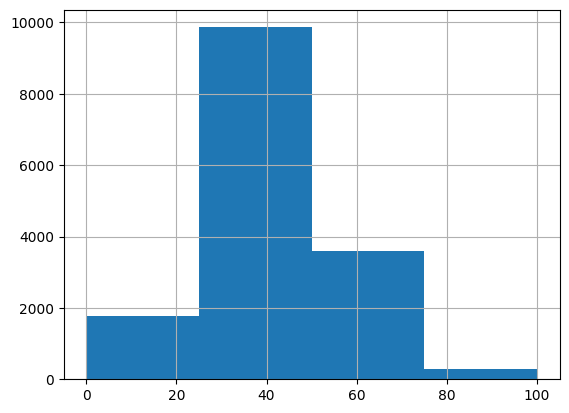

In [ ]:
film_df['age'].hist(bins=[0, 25, 50, 75, 100])